# 🤖 EfficientNetB0 Transfer Learning – staged fine-tuning

**Binary myopia classification from clinical fundus images**

This notebook converts the transfer learning script provided by the tutor (Abraham Otero) into a cleaner Jupyter Notebook format.  
The model uses **EfficientNetB0 pretrained on ImageNet** as a feature extractor and adds a custom binary classification head for myopia detection.

The training is performed in three stages:

1. **Stage 1 – frozen EfficientNetB0:** only the custom classification head is trained.
2. **Stage 2 – fine-tuning last 20 layers:** the previous model is loaded, the last 20 trainable EfficientNetB0 layers are unfrozen, and the model is recompiled with a lower learning rate.
3. **Stage 3 – fine-tuning last 40 layers:** the Stage 2 model is loaded, the last 40 trainable EfficientNetB0 layers are unfrozen, and the model is recompiled with an even lower learning rate.
4. **Stage 4 – fine-tuning last 60 layers:** the Stage 3 model is loaded, more EfficientNetB0 layers are unfrozen, and the model is trained with a very small learning rate.
5. **Stage 5 – fine-tuning last 80 layers:** the Stage 4 model is loaded, an even deeper portion of EfficientNetB0 is unfrozen, and the model is trained cautiously with a very small learning rate.

The loss function is **Binary Focal Crossentropy**, which gives more importance to difficult examples and to the positive class (Myopia).


-> Stage 1 es el modelo más “puro” de transfer learning: EfficientNetB0 está congelado y solo se entrena la cabeza nueva de clasificación/regresión. Es decir, se usa EfficientNetB0 como extractor fijo de características.

Stage 2-5 son pruebas de fine-tuning: se carga el modelo anterior, se descongela parte de EfficientNetB0 y se deja que algunas capas finales también aprendan con nuestras imágenes de retina.

## 🧠 0. What is and why transfer learning?

Transfer learning means using a neural network that has already learned useful visual patterns from a large dataset, in this case **ImageNet**, and adapting it to a new task.

Here, EfficientNetB0 already contains convolutional filters able to detect general image features such as edges, textures, shapes and local patterns. Instead of training all those filters from zero, we reuse them and train only a small custom head on top. Then, in later stages, we progressively unfreeze some of the final EfficientNetB0 layers so the model can adapt more specifically to fundus images.

This notebook evaluates a transfer learning classification model based on EfficientNetB0 using the FullPreproc image set. Unlike the previous small CNN and ResNet notebooks, this model starts from ImageNet-pretrained visual features and then progressively fine-tunes deeper EfficientNetB0 layers across five stages.

This is useful because it tests whether the weak classification results obtained with the previous CNNs were due to insufficient feature extraction. If transfer learning performs better, then pretrained visual representations may be helping the model detect more informative retinal patterns. If not, then the limitation is more likely related to the dataset, labels, preprocessing or task definition.

The key point in this notebook is not only whether EfficientNetB0 works, but also whether the later fine-tuning stages actually justify their additional computational cost.


## ⚙️ 1. Imports and reproducibility


In [1]:
from __future__ import annotations

#import argparse - not needed
import importlib
import sys
from pathlib import Path
from types import SimpleNamespace #extra addition
from typing import Any

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
)
#from sklearn.model_selection import train_test_split - we import now
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt #extra addition


#extra addition ----------------------------------------
SEED = 42 #
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Determinism could not be enabled:", e)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 🧾 2. Experiment configuration

These values can be adapteed if a different experiment is wanted (adapting the number of epochs, batch size...)

Important detail: this EfficientNetB0 implementation keeps images in the **0–255 pixel range**. This is different from some of the previous notebooks where images were converted to **0–1**.


In [2]:
# Experiment selected in config.yaml
EXPERIMENT = "full_preproc"

# Model/loss settings
HEAD = "mlp"
EFFICIENTNET_WEIGHTS = "imagenet"
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0
THRESHOLD = 0.5

# Training settings - extra addition (#)
EPOCHS = 50 #
BATCH_SIZE_OVERRIDE = 16 # - Use None to read batch size from config.yaml
BASE_LEARNING_RATE = 1e-4 #
EARLY_STOPPING_PATIENCE = 5 #
REDUCE_LR_PATIENCE = 5 #
VERBOSE = 2 #

# Optional: force a project root manually if automatic detection fails.
# Example: PROJECT_ROOT_OVERRIDE = r"C:/Users/Paula/Desktop/TFG_Biomed"
PROJECT_ROOT_OVERRIDE = None # Extra addition

STAGES = [
    {
        "stage": 1,
        "name": "stage1_frozen",
        "unfreeze_last_n_layers": 0,
        "lr_multiplier": 1.0,
    },
    {
        "stage": 2,
        "name": "stage2_unfreeze20",
        "unfreeze_last_n_layers": 20,
        "lr_multiplier": 0.1,
    },
    {
        "stage": 3,
        "name": "stage3_unfreeze40",
        "unfreeze_last_n_layers": 40,
        "lr_multiplier": 0.01,
    },
    {
        "stage": 4,
        "name": "stage4_unfreeze60",
        "unfreeze_last_n_layers": 60,
        "lr_multiplier": 0.005,
    },
    {
        "stage": 5,
        "name": "stage5_unfreeze80",
        "unfreeze_last_n_layers": 80,
        "lr_multiplier": 0.002,
    },
]

#extra addition
args = SimpleNamespace(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_OVERRIDE,
    learning_rate=BASE_LEARNING_RATE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    reduce_lr_patience=REDUCE_LR_PATIENCE,
    verbose=VERBOSE,
)


## 📁 3. Project paths

This cell searches for `config.yaml` and imports the helper functions from `src.paths`.

The notebook should be run from inside the project folder, or if failing, set `PROJECT_ROOT_OVERRIDE` in the previous cell.


In [3]:
def find_project_root(start: Path | None = None) -> Path: #extra addition: fixed for congif.yaml possible failure
    if PROJECT_ROOT_OVERRIDE is not None: 
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "config.yaml").exists():
            raise FileNotFoundError(f"config.yaml was not found in PROJECT_ROOT_OVERRIDE: {root}")
        return root

    root = (start or Path.cwd()).resolve()
    while not (root / "config.yaml").exists():
        if root == root.parent:
            raise FileNotFoundError(
                "config.yaml was not found. Run this notebook from inside the project "
                "or set PROJECT_ROOT_OVERRIDE in the configuration cell."
            )
        root = root.parent
    return root

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (  # noqa: E402
    get_experiment_paths,
    get_paths,
    load_config,
    validate_experiment_paths,
    validate_main_structure,
)

In [4]:
# parse_args function would be here, but I believe there is no longer need for it
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Train only the FullPreproc binary myopia classification model."
    )
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument(
        "--early-stopping-patience",
        type=int,
        default=15,
        help="Epochs without val_auc improvement before stopping training.",
    )
    parser.add_argument(
        "--reduce-lr-patience",
        type=int,
        default=5,
        help="Epochs without val_auc improvement before reducing the learning rate.",
    )
    parser.add_argument(
        "--verbose",
        type=int,
        choices=[0, 1, 2],
        default=1,
        help="Keras console verbosity: 0=silent, 1=progress bar, 2=one line per epoch.",
    )
    return parser.parse_args()


In [5]:
# These are extra additions to read variables from config.yaml

cfg = load_config(PROJECT_ROOT / "config.yaml")
paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, EXPERIMENT)
validate_experiment_paths(exp_paths)

seed = int(cfg["settings"].get("seed", SEED))
image_size = tuple(cfg["settings"]["image_size"])
batch_size = args.batch_size or int(cfg["settings"]["batch_size"])

TABLE_PATH = exp_paths["table"]
SPLIT_DIR = exp_paths["split_classification"]
MODELS_DIR = exp_paths["models_experiment"] #from yaml
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
Image size: (224, 224)
Batch size: 16
Seed: 42


## 🧹 4. Load and clean the matched table

The table is expected to contain at least these columns:

- `image_path`
- `filename`
- `patient_id`
- `class_label`

`class_label = 1` corresponds to **Myopia**, and `class_label = 0` corresponds to **Normal**.


In [6]:
def resolve_project_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def resolve_project_path_str(path: str | Path) -> str:
    return str(resolve_project_path(path))

def load_and_clean_table(table_path: Path) -> pd.DataFrame:
    df = pd.read_excel(table_path)
    
    #extra addition
    required_cols = {"image_path", "filename", "patient_id", "class_label"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols: 
        raise ValueError(f"Missing required columns in matched table: {missing_cols}")

    df = df[df["image_path"].notna()].copy()
    df = df[df["class_label"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["image_path", "filename", "patient_id", "class_label"]).copy()
    df["class_label"] = df["class_label"].astype("int32")

    missing_paths = df["image_path"].apply(lambda p: not resolve_project_path(p).exists()).sum()
    if missing_paths:
        raise FileNotFoundError(
            f"{missing_paths} image paths from the match table do not exist. "
            "Check whether image_path values are relative to PROJECT_ROOT."
        )

    return df

#extra addition: loading the table into a df to show it
df = load_and_clean_table(TABLE_PATH)

print("Total valid images:", len(df))
print("Patients:", df["patient_id"].nunique())
print("Classification label balance:")
print(df["class_label"].value_counts())
display(df.head())


Total valid images: 2126
Patients: 1061
Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


The notebook uses the same clinical image dataset as the previous classification experiments: **2,126 valid images**, belonging to **1,061 patients**. The class distribution remains strongly imbalanced, with **1,645 normal images** and **481 myopic images**.

This means that normal images represent approximately **77%** of the dataset and myopic images approximately **23%**. Therefore, a naive classifier predicting all test images as normal would already obtain an accuracy around **0.78**.

For this reason, accuracy alone is not enough to evaluate this model. The most useful metrics are **AUC**, **Average Precision**, **myopia recall**, **myopia precision** and the confusion matrices. This is especially important because this notebook uses focal loss, which can alter the model's threshold behaviour.


## ✂️ 5. Patient-level train/validation/test splits

This notebook loads the patient-level classification splits created in 
00_CreatePatientLevelSplits_Classf_Regrss.ipynb.

It does not create new splits.


In [7]:
# Load and validate existing patient-level classification splits
# These splits were created in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_splits(split_dir: Path) -> dict[str, pd.DataFrame]:
    split_files = {
        name: split_dir / f"{name}.csv"
        for name in ["train", "val", "test"]
    }

    for split_name, split_path in split_files.items():
        if not split_path.exists():
            raise FileNotFoundError(
                f"Missing {split_name} split file: {split_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        split_name: pd.read_csv(split_path)
        for split_name, split_path in split_files.items()
    }


def assert_no_overlap(split_dfs: dict[str, pd.DataFrame], column: str, name: str) -> None:
    split_sets = {
        split_name: set(split_df[column].astype(str))
        for split_name, split_df in split_dfs.items()
    }

    pairs = [("train", "val"), ("train", "test"), ("val", "test")]

    for left, right in pairs:
        overlap = split_sets[left] & split_sets[right]
        if overlap:
            raise AssertionError(
                f"{name} leakage detected between {left} and {right}: "
                f"{len(overlap)} overlapping values. Example: {list(overlap)[:5]}"
            )

    print(f"OK: no {name} overlap across train/val/test.")


def validate_classification_splits(split_dfs: dict[str, pd.DataFrame]) -> None:
    required_cols = {"image_path", "patient_id", "class_label"}

    for split_name, split_df in split_dfs.items():
        missing_cols = required_cols - set(split_df.columns)
        if missing_cols:
            raise ValueError(f"{split_name} split is missing columns: {missing_cols}")

        split_df["class_label"] = split_df["class_label"].astype(int)

        print(
            f"{split_name}: {len(split_df)} images, "
            f"{split_df['patient_id'].nunique()} patients"
        )

    assert_no_overlap(split_dfs, "patient_id", "patient")
    assert_no_overlap(split_dfs, "image_path", "image")

    print("\nClassification balance:")
    for split_name, split_df in split_dfs.items():
        print(f"\n{split_name}")
        print(split_df["class_label"].value_counts(normalize=True))
        print(split_df["class_label"].value_counts())


split_dfs = load_existing_splits(SPLIT_DIR)
validate_classification_splits(split_dfs)

train: 1701 images, 848 patients
val: 211 images, 106 patients
test: 214 images, 107 patients
OK: no patient overlap across train/val/test.
OK: no image overlap across train/val/test.

Classification balance:

train
class_label
0    0.771899
1    0.228101
Name: proportion, dtype: float64
class_label
0    1313
1     388
Name: count, dtype: int64

val
class_label
0    0.781991
1    0.218009
Name: proportion, dtype: float64
class_label
0    165
1     46
Name: count, dtype: int64

test
class_label
0    0.780374
1    0.219626
Name: proportion, dtype: float64
class_label
0    167
1     47
Name: count, dtype: int64


The classification split contains **1,701 training images**, **211 validation images** and **214 test images**. The checks confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets.

The class proportions are also similar across train, validation and test sets. Therefore, differences in performance across stages should mainly be attributed to the model and fine-tuning strategy, rather than to a problematic data split.


## 🧮 6. TensorFlow datasets

This dataloader reads image paths from the split CSV files.

Unlike previous notebooks where images were converted to `[0, 1]`, here images are only cast to `float32`, keeping their values in the `[0, 255]` range before entering EfficientNetB0.


In [8]:
def make_datasets(
    split_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    seed: int,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    autotune = tf.data.AUTOTUNE
    shuffle_buffer_size = 2048

    augment = keras.Sequential( #extra: augmentations before decode_img
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.05),
        ],
        name="light_augmentation",
    )

    def decode_img(path, y):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.ensure_shape(img, [None, None, 3])
        img = tf.image.resize(img, image_size, method="bilinear")
        img = tf.cast(img, tf.float32)  # Keep pixel range 0-255 for EfficientNetB0
        return img, tf.cast(y, tf.float32)

    def make_classification_ds(csv_path: Path, training: bool = False) -> tf.data.Dataset:
        df_split = pd.read_csv(csv_path)
        paths = df_split["image_path"].map(resolve_project_path_str).astype(str).values
        labels = df_split["class_label"].astype("float32").values

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(decode_img, num_parallel_calls=autotune)

        if training:
            ds = ds.shuffle(
                shuffle_buffer_size,
                seed=seed,
                reshuffle_each_iteration=True,
            )
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=autotune)

        return ds.batch(batch_size).prefetch(autotune)

    return (
        make_classification_ds(split_dir / "train.csv", training=True),
        make_classification_ds(split_dir / "val.csv", training=False),
        make_classification_ds(split_dir / "test.csv", training=False),
    )

#extra: splitting here and now...
train_ds, val_ds, test_ds = make_datasets(
    split_dir=SPLIT_DIR,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
)

#... and checking performance before moving on
for xb, yb in train_ds.take(1):
    print("Batch image shape:", xb.shape)
    print("Batch label shape:", yb.shape)
    print("Pixel range in batch:", float(tf.reduce_min(xb)), "to", float(tf.reduce_max(xb)))


Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Pixel range in batch: 0.0 to 255.0


Note!!: pixel range and EfficientNetB0 preprocessing

This notebook keeps image pixels in the **0–255 range** before passing them to EfficientNetB0. This differs from the earlier small CNN notebooks, where images were typically normalized to **0–1**.

This difference is appropriate here because EfficientNet-style models usually expect their own preprocessing pipeline. However, it also means that comparisons with earlier notebooks should be interpreted as comparisons between complete modelling pipelines, not only between architectures.

The batch inspection confirms that the input images have shape **224×224×3**, matching the expected EfficientNetB0 input size.


## 🧩 7. EfficientNetB0 model definition

The model uses **EfficientNetB0 without its original classification head**, followed by a custom binary head:

`GlobalAveragePooling2D → BatchNormalization → Dense(256) → Dropout(0.4) → Dense(64) → Dropout(0.2) → Dense(1, sigmoid)`

Stage 1 keeps EfficientNetB0 frozen and trains only the custom classification head. Stages 2–5 progressively unfreeze the last **20, 40, 60 and 80 EfficientNetB0 layers**, respectively, using increasingly small learning rates.

This design allows us to test two things separately: first, whether pretrained ImageNet features are already useful for retinal classification; and second, whether adapting deeper EfficientNetB0 layers to fundus images improves performance.

Compared with the previous **ResNet FullPreproc** notebook, this architecture has fewer parameters than the custom residual model but benefits from pretrained visual representations. Therefore, if it performs better, the improvement is likely due to transfer learning rather than simply model size.

In [9]:
def configure_efficientnet_base_trainability( #switching this function to top of cell bc function below uses it (no need, but maked more sense "chronologically")
    base_model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model.trainable = bool(unfreeze_last_n_layers)

    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    if not unfreeze_last_n_layers:
        return

    # BatchNorm layers are kept frozen during fine-tuning for stability
    trainable_layers = [
        layer
        for layer in base_model.layers
        if not isinstance(layer, layers.BatchNormalization)
    ]

    for layer in trainable_layers[-unfreeze_last_n_layers:]:
        layer.trainable = True

def build_efficientnetb0_classification(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")
    
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=EFFICIENTNET_WEIGHTS,
        input_shape=input_shape,
    )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=bool(unfreeze_last_n_layers))
    x = layers.GlobalAveragePooling2D()(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_classification")

def find_efficientnet_base(model: keras.Model) -> keras.Model | None:
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("efficientnet"):
            return layer
    return None


def configure_loaded_model_for_fine_tuning(
    model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        raise ValueError(
            "The loaded model does not contain an EfficientNet base. "
            "Check the previous stage model path."
        )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)


def count_trainable_base_layers(model: keras.Model) -> int | None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        return None
    return sum(
        1
        for layer in base_model.layers
        if layer.trainable and not isinstance(layer, layers.BatchNormalization)
    )


In [10]:
#These fucntions were supposed to be here, but I believe there's no need for them anymore:
def build_classification_model(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    return build_efficientnetb0_classification(
        input_shape=input_shape,
        unfreeze_last_n_layers=unfreeze_last_n_layers,
    )

## 🎯 8. Loss, optimizer, callbacks and metrics


In [11]:
def build_loss() -> keras.losses.Loss:
    return keras.losses.BinaryFocalCrossentropy(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        apply_class_balancing=True,
    )

def compile_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=build_loss(),
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
    )

#Extra: moving this function up here (makes sense chronologically)
class EpochConsoleLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None) -> None:
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        metric_names = ["loss", "auc", "accuracy", "val_loss", "val_auc", "val_accuracy"]
        metrics = []

        for name in metric_names:
            if name in logs:
                metrics.append(f"{name}={float(logs[name]):.6f}")

        metrics.append(f"lr={lr:.2e}")
        print(f"Epoch {epoch + 1}: " + " | ".join(metrics), flush=True)


def make_callbacks(args: SimpleNamespace) -> list[keras.callbacks.Callback]:
    return [
        EpochConsoleLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=args.early_stopping_patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.3,
            patience=args.reduce_lr_patience,
        ),
    ]


## 📊 9. Evaluation helpers

These functions calculate AUC, AP, accuracy, recall for myopia, confusion matrix and classification report.


In [12]:
def collect_classification_preds(
    model: keras.Model,
    ds: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray]:
    y_true, y_score = [], []

    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())

    return np.array(y_true).astype(int), np.array(y_score).astype(float)

def evaluate_classification( model: keras.Model, test_ds: tf.data.Dataset, threshold: float = THRESHOLD) -> dict[str, Any]:
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"],
        output_dict=True,
        zero_division=0, #helps for errors found on previous notebooks with 0 division, when plotting
    )

    print(classification_report(y_true, y_pred, target_names=["Normal", "Myopia"], zero_division=0))
    print("Confusion matrix:\n", cm)
    print(f"AUC: {roc_auc:.6f}")
    print(f"AP: {ap:.6f}")
    print(f"Accuracy@{threshold}: {(y_pred == y_true).mean():.6f}")

    return { #added a couple more vars to return (#)
        "auc": float(roc_auc),
        "average_precision": float(ap),
        f"accuracy@{threshold}": float((y_pred == y_true).mean()),
        "recall_myopia": float(report["Myopia"]["recall"]), #
        "precision_myopia": float(report["Myopia"]["precision"]), #
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
        "fpr": fpr.tolist(), #
        "tpr": tpr.tolist(), #
        "precision_curve": precision.tolist(),
        "recall_curve": recall.tolist(),
        "y_true": y_true.tolist(), #
        "y_score": y_score.tolist(), #
        "y_pred": y_pred.tolist(), #
    }


## 💾 10. Output paths and stage training function


In [13]:
#extra addition: one route per stage (per model)
def stage_output_paths(models_dir: Path, stage: dict[str, Any]) -> tuple[Path, Path, Path]:
    stem = f"transfer_learning_classification_with_dropout_fullpreproc_{stage['name']}"
    
    stage_model_path = models_dir / f"{stem}.keras"
    stage_summary_path = models_dir / f"{stem}_summary.json"
    stage_preds_path = models_dir / f"{stem}_predictions.csv"
    
    return stage_model_path, stage_summary_path, stage_preds_path

def train_stage( #extra: moved here for chr. sense
    stage: dict[str, Any],
    args: SimpleNamespace,
    input_shape: tuple[int, int, int],
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    test_ds: tf.data.Dataset,
    models_dir: Path,
    previous_model_path: Path | None,
    common_summary: dict[str, Any],
) -> tuple[dict[str, Any], dict[str, list[float]]]:
    stage_model_path, stage_summary_path, stage_preds_path = stage_output_paths(models_dir, stage)    
    stage_lr = args.learning_rate * float(stage["lr_multiplier"])
    unfreeze_last_n_layers = int(stage["unfreeze_last_n_layers"])

    print("\n" + "=" * 72)
    print(f"Stage {stage['stage']}: {stage['name']}")
    print("Initial model:", previous_model_path)
    print("Unfreeze last N EfficientNetB0 layers:", unfreeze_last_n_layers)
    print("Learning rate:", stage_lr)
    print("Epochs requested:", args.epochs)
    print("=" * 72)

    if previous_model_path is None:
        model = build_efficientnetb0_classification(
            input_shape=input_shape,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )
    else:
        model = keras.models.load_model(previous_model_path, compile=False)
        configure_loaded_model_for_fine_tuning(
            model=model,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )

    trainable_base_layers = count_trainable_base_layers(model)
    print("EfficientNetB0 trainable base layers:", trainable_base_layers)

    compile_model(model, stage_lr)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epochs,
        callbacks=make_callbacks(args),
        verbose=args.verbose,
    )

    print("Keras test metrics:")
    keras_metrics = model.evaluate(test_ds, return_dict=True)
    print(keras_metrics)

    eval_metrics = evaluate_classification(model, test_ds, threshold=THRESHOLD)

    preds_df = pd.DataFrame({ #extra: for later (possibility for saving below as well)
        "y_true": eval_metrics["y_true"],
        "y_score": eval_metrics["y_score"],
        "y_pred": eval_metrics["y_pred"],
    })
    #preds_df.to_csv(stage_preds_path, index=False)
    #print("Stage predictions saved at:", stage_preds_path)

    model.save(stage_model_path)
    print("Stage model saved at:", stage_model_path)

    stage_summary = {
        **common_summary,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "model_path": str(stage_model_path),
        "predictions_path": str(stage_preds_path),
        "initial_model_path": str(previous_model_path) if previous_model_path else None,
        "learning_rate": stage_lr,
        "base_learning_rate": args.learning_rate,
        "lr_multiplier": float(stage["lr_multiplier"]),
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "trainable_base_layers": trainable_base_layers,
        "epochs_requested": args.epochs,
        "epochs_run": len(history.history.get("loss", [])),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "keras_test_metrics": {k: float(v) for k, v in keras_metrics.items()},
        "evaluation": {
            k: v for k, v in eval_metrics.items()
            if k not in {"y_true", "y_score", "y_pred"}
        },
    }

    return stage_summary, history.history #returnign history as well for plotting


## 🚀 11. Run the five training stages

This cell trains the full staged pipeline (what would've been the "main function").  
Each stage loads the previous model, recompiles it with its own learning rate, trains, evaluates and saves outputs.


In [14]:
input_shape = (*image_size, 3)

common_summary = {
    "table_path": str(TABLE_PATH),
    "split_dir": str(SPLIT_DIR),
    "experiment": EXPERIMENT,
    "image_size": list(image_size),
    "batch_size": batch_size,
    "seed": seed,
    "architecture": "efficientnetb0",
    "head": HEAD,
    "efficientnet_weights": EFFICIENTNET_WEIGHTS,
    "image_pixel_range": "0-255",
    "loss": "binary_focal_crossentropy",
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "threshold": THRESHOLD,
}

stage_summaries = []
stage_histories = {}
previous_model_path = None

for stage in STAGES:
    stage_summary, stage_history = train_stage(
        stage=stage,
        args=args,
        input_shape=input_shape,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        models_dir=MODELS_DIR,
        previous_model_path=previous_model_path,
        common_summary=common_summary,
    )

    stage_summaries.append(stage_summary)
    stage_histories[stage["name"]] = stage_history
    previous_model_path = Path(stage_summary["model_path"])

global_summary = {
    **common_summary,
    "base_learning_rate": args.learning_rate,
    "epochs_requested_per_stage": args.epochs,
    "stages": stage_summaries,
}


Stage 1: stage1_frozen
Initial model: None
Unfreeze last N EfficientNetB0 layers: 0
Learning rate: 0.0001
Epochs requested: 50
EfficientNetB0 trainable base layers: 0


Model: "efficientnetb0_classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 3,796,149 (14.48 MB)

 Non-trainable params: 602,991 (2.30 MB)

Epoch 1/50
Epoch 1: loss=0.042931 | auc=0.859684 | accuracy=0.778366 | val_loss=0.048876 | val_auc=0.811199 | val_accuracy=0.777251 | lr=2.00e-07
107/107 - 110s - 1s/step - accuracy: 0.7784 - auc: 0.8597 - loss: 0.0429 - val_accuracy: 0.7773 - val_auc: 0.8112 - val_loss: 0.0489 - learning_rate: 2.0000e-07
Epoch 2/50
Epoch 2: loss=0.044582 | auc=0.847160 | accuracy=0.757202 | val_loss=0.048828 | val_auc=0.812516 | val_accuracy=0.777251 | lr=2.00e-07
107/107 - 94s - 881ms/step - accuracy: 0.7572 - auc: 0.8472 - loss: 0.0446 - val_accuracy: 0.7773 - val_auc: 0.8125 - val_loss: 0.0488 - learning_rate: 2.0000e-07
Epoch 3/50
Epoch 3: loss=0.043266 | auc=0.858154 | accuracy=0.767784 | val_loss=0.048737 | val_auc=0.812319 | val_accuracy=0.772512 | lr=2.00e-07
107/107 - 89s - 829ms/step - accuracy: 0.7678 - auc: 0.8582 - loss: 0.0433 - val_accuracy: 0.7725 - val_auc: 0.8123 - val_loss: 0.0487 - learning_rate: 2.0000e-07
Epoch 4/50
Epoch 4: loss=0.045057 | auc=0.838851 | accuracy=0.746620 | val_

The five stages show a clear pattern. Stage 1, with EfficientNetB0 frozen, already reaches a useful validation AUC and test AUC. Fine-tuning more layers in stages 2–5 produces only very small improvements in AUC.

The trainable parameter count increases substantially across stages, from approximately **347k trainable parameters** in Stage 1 to approximately **3.8M trainable parameters** in Stage 5. However, the test AUC only increases from **0.725** in Stage 1 to **0.730** in Stage 5.

This means that most of the useful performance is already achieved with the frozen EfficientNetB0 feature extractor. The additional fine-tuning provides marginal gains in AUC, but at the cost of greater model complexity and longer training.

-> Compared with the previous **small_cnn FullPreproc** and **ResNet FullPreproc** notebooks, this is the first full-preprocessing classification approach that clearly improves the global ranking of normal vs myopic images!!! However, the threshold-based behaviour still needs caution, because myopia precision remains low.


## 📋 12. Results table

This table is formatted similarly to the rest of the notebooks: AUC, AP, accuracy and recall for myopia.


In [15]:
results_rows = []

for summary in stage_summaries:
    ev = summary["evaluation"]
    results_rows.append({
        "stage": summary["stage"],
        "stage_name": summary["stage_name"],
        "unfreeze_last_n_layers": summary["unfreeze_last_n_layers"],
        "learning_rate": summary["learning_rate"],
        "epochs_run": summary["epochs_run"],
        "best_val_auc": summary["best_val_auc"],
        "test_auc": ev["auc"],
        "test_ap": ev["average_precision"],
        f"test_accuracy@{THRESHOLD}": ev[f"accuracy@{THRESHOLD}"],
        "test_recall_myopia": ev["recall_myopia"],
        "test_precision_myopia": ev["precision_myopia"],
        "model_path": summary["model_path"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,stage,stage_name,unfreeze_last_n_layers,learning_rate,epochs_run,best_val_auc,test_auc,test_ap,test_accuracy@0.5,test_recall_myopia,test_precision_myopia,model_path
0,1,stage1_frozen,0,1.000000e-04,33,0.802701,0.725443,0.457061,0.658879,0.680851,0.355556,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,2,stage2_unfreeze20,20,1.000000e-05,12,0.814493,0.727609,0.448118,0.677570,0.702128,0.375000,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,3,stage3_unfreeze40,40,1.000000e-06,7,0.816008,0.727863,0.442376,0.691589,0.702128,0.388235,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,4,stage4_unfreeze60,60,5.000000e-07,6,0.813702,0.728628,0.442802,0.691589,0.702128,0.388235,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
4,5,stage5_unfreeze80,80,2.000000e-07,10,0.813900,0.729647,0.439579,0.686916,0.702128,0.383721,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


The results table shows that all five stages perform very similarly. The best stage by **test AUC** is **Stage 5**, with **AUC = 0.7296**, but the improvement over Stage 1 is very small. Stage 1 already obtains **AUC = 0.7254**.

The best **Average Precision** is actually obtained by **Stage 1**, with **AP = 0.4571**. AP then decreases slightly across later stages, reaching **0.4396** in Stage 5. This suggests that fine-tuning improves the global ROC ranking very slightly, but does not improve the minority-class Precision-Recall behaviour.

The best threshold-based accuracy is obtained by **Stages 3 and 4**, both with **accuracy = 0.6916**. However, this is still below the majority-class baseline of approximately **0.78**, so it should not be interpreted as a strong standalone result.

The myopia recall is high and stable from Stage 2 onwards, around **0.702**, but myopia precision remains low, around **0.38–0.39**. Therefore, the model detects a relatively high proportion of myopic cases but produces many false positives among normal images.

-> Compared with the earlier classification notebooks, this is a meaningful improvement in AUC and AP. The best selective small CNNs reached AUC values around **0.61–0.62**, while this EfficientNetB0 model reaches approximately **0.73**. This indicates that transfer learning is helping the model learn a stronger visual ranking than the small CNNs.


## 📈 13. Training curves


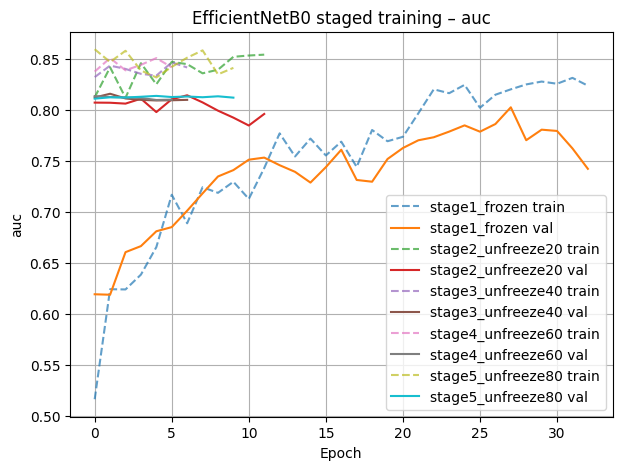

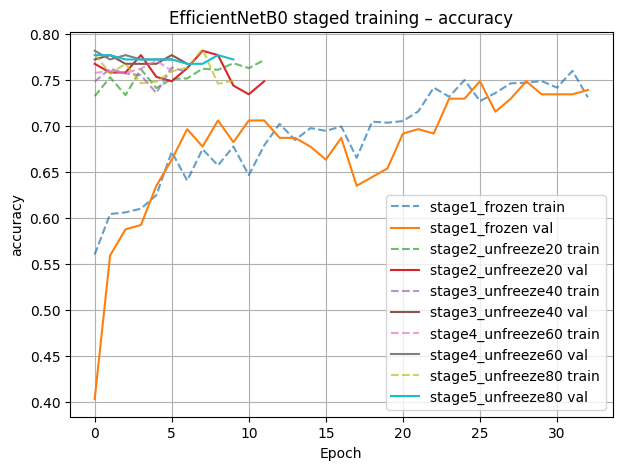

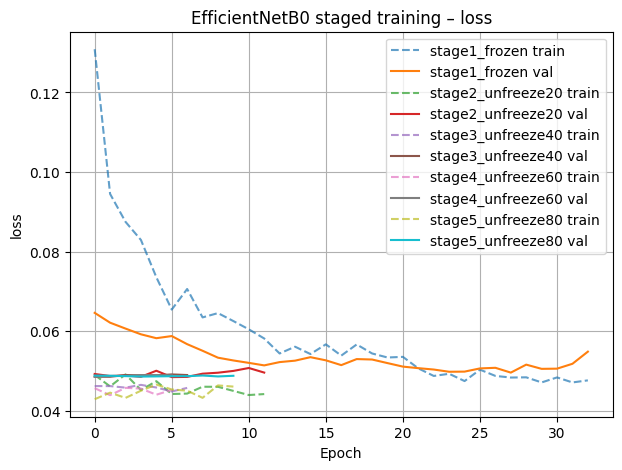

In [16]:
def plot_stage_histories(histories_dict: dict[str, dict[str, list[float]]], metric: str = "auc") -> None:
    plt.figure(figsize=(7, 5))

    for name, history in histories_dict.items():
        if metric in history:
            plt.plot(history[metric], linestyle="--", alpha=0.7, label=f"{name} train")
        if f"val_{metric}" in history:
            plt.plot(history[f"val_{metric}"], label=f"{name} val")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"EfficientNetB0 staged training – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stage_histories(stage_histories, metric="auc")
plot_stage_histories(stage_histories, metric="accuracy")
plot_stage_histories(stage_histories, metric="loss")


The training curves show that Stage 1 improves progressively over many epochs, while later stages run for fewer epochs and mainly fine-tune around an already learned solution.

Validation AUC improves clearly during Stage 1 and then stays within a narrow range in later stages. This supports the idea that the frozen EfficientNetB0 extractor already provides most of the useful signal, and later unfreezing only adjusts the model slightly.

Validation accuracy is less informative because of class imbalance and threshold effects. A model can have a better AUC while still showing limited accuracy at threshold 0.5 if its predicted probabilities are not well calibrated.

-> Compared with the small CNN notebooks, these curves look more promising because validation AUC reaches around **0.80–0.82**, whereas the previous small CNN validation AUCs were much closer to random-to-moderate performance. Nevertheless, this better validation ranking does not fully translate into a clinically reliable default-threshold classifier.


## 📉 14. ROC and Precision-Recall curves


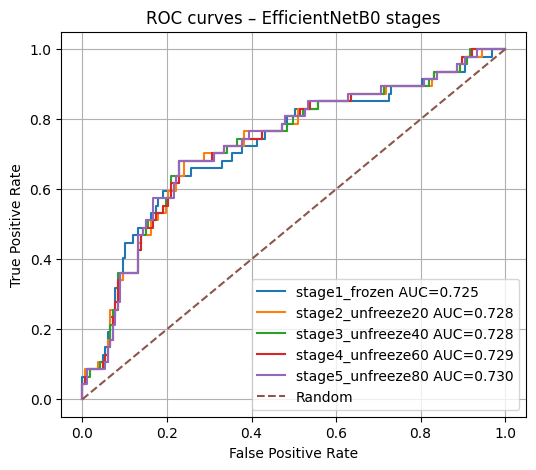

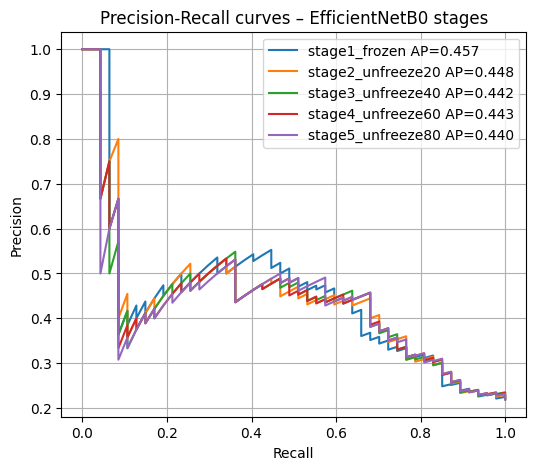

In [17]:
def plot_roc_pr_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["fpr"], ev["tpr"], label=f"{summary['stage_name']} AUC={ev['auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["recall_curve"], ev["precision_curve"], label=f"{summary['stage_name']} AP={ev['average_precision']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_pr_from_summaries(stage_summaries)

The ROC curves for the five stages almost overlap, confirming that fine-tuning deeper EfficientNetB0 layers only changes performance marginally. The best AUC belongs to Stage 5, but the difference from Stage 1 is very small.

The Precision-Recall curves are also close to each other. Stage 1 has the highest AP, while later stages trade a small AUC gain for slightly lower AP. This is important because AP is particularly relevant in this imbalanced dataset, where myopia is the minority class.

-> Compared with previous notebooks, the EfficientNetB0 curves are clearly better than the small CNN selective and full-preprocessing curves. The AP values around **0.44–0.46** are also higher than the earlier small CNN AP values, which were generally around **0.30–0.34**.



## 🔢 15. Confusion matrices


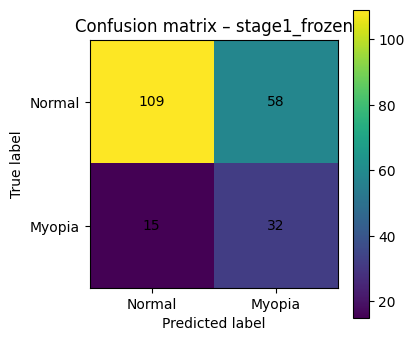

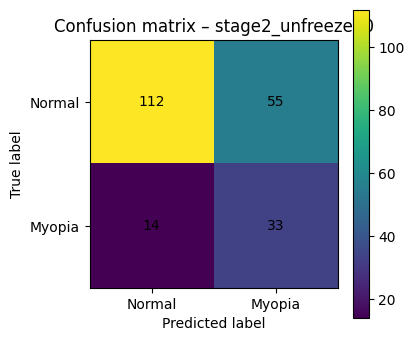

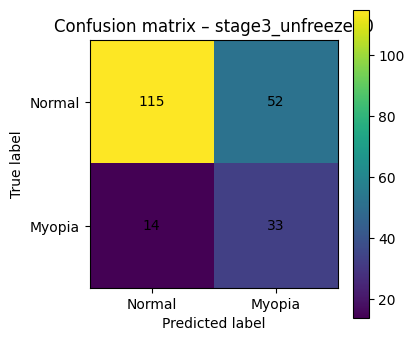

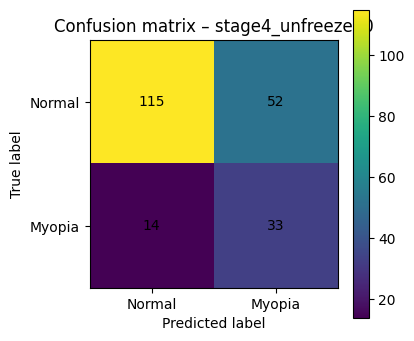

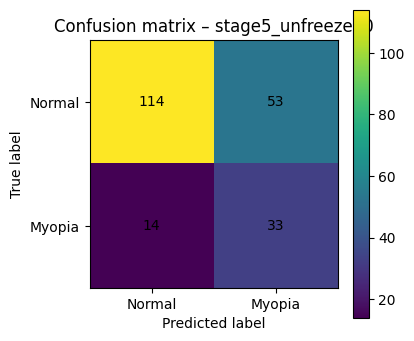

In [18]:
def plot_confusion_matrix(cm: list[list[int]], title: str) -> None:
    cm_arr = np.array(cm)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm_arr)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Normal", "Myopia"])
    plt.yticks([0, 1], ["Normal", "Myopia"])

    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            plt.text(j, i, str(cm_arr[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.show()

for summary in stage_summaries:
    plot_confusion_matrix(
        summary["evaluation"]["confusion_matrix"],
        title=f"Confusion matrix – {summary['stage_name']}",
    )

The confusion matrices show that the model identifies many myopic cases, but also misclassifies a considerable number of normal images as myopic.

For the best-AUC model, **Stage 5**, the confusion matrix is:
- **114 true normals**
- **53 false positives**
- **14 false negatives**
- **33 true myopic cases**

This corresponds to a myopia recall of approximately **0.70**, meaning that the model detects about 70% of myopic images. However, myopia precision is only approximately **0.38**, meaning that many images predicted as myopic are actually normal.

Compared with the **ResNet FullPreproc** notebook, this is a clear improvement. The ResNet model tended to classify almost everything as myopic, while EfficientNetB0 keeps a more balanced confusion matrix. Compared with the **small_cnn FullPreproc** model with Dropout, EfficientNetB0 also improves myopia recall and AUC, but still produces many false positives.

-> Therefore, the model is better as a ranking/screening model than as a final thresholded classifier. Its default threshold of 0.5 is maybe not optimal??


## 📝 16. Results template (test)

Short text skeleton that can be adapted for the TFG results section.


In [19]:
best_auc_row = results_df.sort_values("test_auc", ascending=False).iloc[0]
best_recall_row = results_df.sort_values("test_recall_myopia", ascending=False).iloc[0]

print("Best stage by AUC:")
print(best_auc_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])
print("\nBest stage by myopia recall:")
print(best_recall_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])

Best stage by AUC:
stage_name            stage5_unfreeze80
test_auc                       0.729647
test_accuracy@0.5              0.686916
test_recall_myopia             0.702128
Name: 4, dtype: object

Best stage by myopia recall:
stage_name            stage2_unfreeze20
test_auc                       0.727609
test_accuracy@0.5               0.67757
test_recall_myopia             0.702128
Name: 1, dtype: object


-> Clasificación: Stage 2 mejora AUC mínimamente, pero Stage 1 tiene mejor recall de miopía empleando muchos menos parámetros.

This notebook evaluates a **staged EfficientNetB0 transfer learning classifier** using the **FullPreproc** image set. The model is trained in five stages: first with the EfficientNetB0 base frozen, and then progressively unfreezing the last 20, 40, 60 and 80 layers.

The main result is that transfer learning improves classification performance compared with the previous small CNN and ResNet FullPreproc models. The best stage by test AUC is **Stage 5**, with **AUC = 0.7296**, **AP = 0.4396**, **accuracy = 0.6869** and **myopia recall = 0.7021**. This is clearly higher than the previous small CNN selective models, which stayed around **AUC = 0.60–0.62**, and also higher than the custom ResNet model, which reached only around **AUC = 0.61**.

However, the improvement does not make the model clinically robust by itself. The threshold-based accuracy remains below the majority-class baseline of approximately **0.78**, and myopia precision remains low, around **0.38**. This means that the model detects many myopic cases, but also generates many false positives among normal images.

The staged fine-tuning strategy provides only marginal improvement over the frozen model. Stage 1 already obtains **AUC = 0.7254** and the best **AP = 0.4571**, while Stage 5 only increases AUC to **0.7296** and slightly lowers AP. Therefore, most of the useful information comes from the pretrained EfficientNetB0 features and the custom head, not from extensive fine-tuning.

This is an important comparison with the previous ResNet notebook. The ResNet model had more than 11 million parameters and still failed to improve classification, while EfficientNetB0 achieves better AUC with a pretrained backbone. This suggests that pretrained representations are more useful than simply increasing architecture depth from scratch.

Compared with the previous regression notebooks, classification continues to be more promising than direct **SE** prediction. The regression models repeatedly produced R² values close to zero and predictions collapsed around the mean **SE**, while this classifier at least learns a meaningful ranking between normal and myopic images.

All in all:

This notebook shows that **EfficientNetB0 transfer learning is the strongest FullPreproc classification approach tested so far**, especially in terms of AUC and AP. Nevertheless, the model should not be interpreted as a final clinical classifier without further work. The next steps would be threshold calibration, comparison against selective preprocessing transfer learning, possible patient-level aggregation, and careful discussion of false positives/false negatives.
